In [1]:
!pip install -q kaggle

In [8]:
from google.colab import files
files.upload()  # Upload kaggle.json



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pavankumarpatale","key":"783bc72a7f060ac831ef144eaf0fcc94"}'}

In [9]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip brain-mri-images-for-brain-tumor-detection.zip -d ./MRI_BRAIN

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
Archive:  brain-mri-images-for-brain-tumor-detection.zip
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/1 no.jpeg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/10 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/11 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/12 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/13 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/14 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/15 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/17 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/18 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/19 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/2 no.jpeg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/20 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor_dataset/no/21 no.jpg  
  inflating: ./MRI_BRAIN/brain_tumor

In [11]:
import os
import glob
import numpy as np
import cv2
import tensorflow as tf

# Preprocessing for 2D CNN
def preprocess_mri_jpg(file_path, target_shape=(128, 128)):
    file_path = file_path.numpy().decode('utf-8')
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, target_shape)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)  # shape: (128, 128, 1)
    return img

# TensorFlow Dataset Creator
def create_dataset(tumor_dir, no_tumor_dir, batch_size=8):
    tumor_files = glob.glob(os.path.join(tumor_dir, "*.jpg"))
    no_tumor_files = glob.glob(os.path.join(no_tumor_dir, "*.jpg"))

    file_paths = np.array(tumor_files + no_tumor_files)
    labels = np.array([1] * len(tumor_files) + [0] * len(no_tumor_files))

    indices = np.arange(len(file_paths))
    np.random.shuffle(indices)

    file_paths, labels = file_paths[indices], labels[indices]

    def load_and_preprocess(file_path, label):
        image = tf.py_function(func=preprocess_mri_jpg, inp=[file_path], Tout=tf.float32)
        image.set_shape((128, 128, 1))
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# 2D CNN Model
def build_2d_cnn(input_shape=(128, 128, 1)):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Main training
tumor_dir = "./MRI_BRAIN/yes"
no_tumor_dir = "./MRI_BRAIN/no"
batch_size = 8

dataset = create_dataset(tumor_dir, no_tumor_dir, batch_size)
model = build_2d_cnn()

model.fit(dataset, epochs=10)
model.save("brain_tumor_model_2d.h5")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 537ms/step - accuracy: 0.5439 - loss: 0.6908
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 522ms/step - accuracy: 0.7028 - loss: 0.5801
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 529ms/step - accuracy: 0.6855 - loss: 0.6057
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 533ms/step - accuracy: 0.7170 - loss: 0.5744
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 533ms/step - accuracy: 0.7209 - loss: 0.5312
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 453ms/step - accuracy: 0.7138 - loss: 0.5102
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 499ms/step - accuracy: 0.7125 - loss: 0.4928
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 473ms/step - accuracy: 0.7929 - loss: 0.4169
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 484ms/step - accuracy: 0.7970 - loss: 0.4221
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 514ms/step - accuracy: 0.8464 - loss: 0.3696


Saving resized_image.jpg to resized_image.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Prediction: Tumor


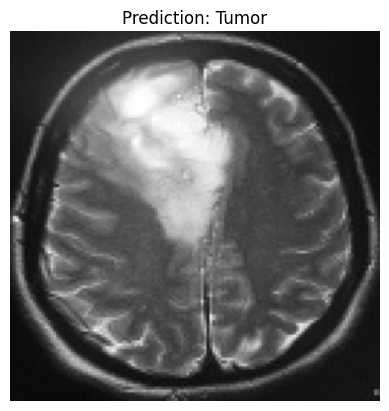

In [12]:
# Load model and test with image
from google.colab import files
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("brain_tumor_model_2d.h5")

# Upload and preprocess image
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
img = img.astype(np.float32) / 255.0
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)  # Batch dimension

prediction = model.predict(img)[0][0]
print("Prediction:", "Tumor" if prediction > 0.5 else "No Tumor")

plt.imshow(cv2.imread(test_image_path), cmap='gray')
plt.title(f"Prediction: {'Tumor' if prediction > 0.5 else 'No Tumor'}")
plt.axis('off')
plt.show()


Saving yes.jpg to yes.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


<ipython-input-22-0343b2a84aab>:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


Prediction: No Tumor


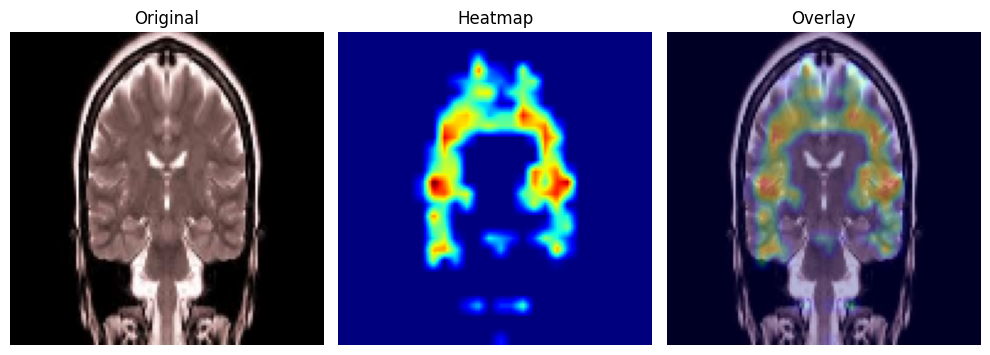

In [22]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load your trained model
model = load_model("brain_tumor_model_2d.h5")

# Define Grad-CAM functions
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create model that maps the input image and the last conv layer
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradient of top predicted class
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of output neuron (top predicted class) with last conv output
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply gradients with the feature map and sum
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Preprocess image function (same as your training preprocessing)
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    return img

# Generate and display heatmap
def display_gradcam(image_path, heatmap, alpha=0.4):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title('Heatmap')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Choose the last convolutional layer from your model
last_conv_layer_name = 'conv2d_2'  # Change this based on your model's layer names

# Upload and process test image
from google.colab import files
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

# Preprocess image
preprocessed_img = preprocess_image(test_image_path)

# Make prediction
prediction = model.predict(preprocessed_img)[0][0]
class_idx = 1 if prediction > 0.5 else 0

# Generate heatmap
heatmap = make_gradcam_heatmap(preprocessed_img, model, last_conv_layer_name, class_idx)

# Display results
print("Prediction:", "Tumor" if prediction > 0.5 else "No Tumor")
display_gradcam(test_image_path, heatmap)